# Entrenamiento y evaluación de modelos — EnergiAI

**Responsable:** Tomás Maldonado (TM)

**Dataset:** `ideal_monthly_features_labeled.parquet`

**Unidad de análisis:** hogar–mes

**Objetivo:** comparar modelos supervisados y seleccionar el mejor mediante
F1 macro con validación cruzada agrupada por vivienda.

Este notebook respeta el contrato de `docs/category_definition.md`:
solo utiliza las cinco variables del endpoint, conserva el split oficial y
nunca mezcla meses de una misma vivienda entre folds.

In [1]:
from __future__ import annotations

import json
import platform
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42
CLASS_ORDER = ["Eficiente", "Moderado", "Ineficiente"]
FEATURE_COLUMNS = [
    "consumo_kwh",
    "uso_horario_pico",
    "cantidad_equipos",
    "tipo_inmueble",
    "horas_alto_consumo",
]
TARGET_COLUMN = "categoria"
GROUP_COLUMN = "homeid"
SPLIT_COLUMN = "split"


def find_repo_root() -> Path:
    """Encuentra la raíz del repositorio desde Jupyter, VS Code o terminal."""
    candidates = [Path.cwd(), *Path.cwd().parents]
    for candidate in candidates:
        expected = candidate / "data" / "processed" / "ideal_monthly_features_labeled.parquet"
        if expected.exists():
            return candidate
    raise FileNotFoundError(
        "No se encontró data/processed/ideal_monthly_features_labeled.parquet. "
        "Ejecute el notebook dentro del repositorio G9-LATAM-Team-51."
    )


REPO_ROOT = find_repo_root()
DATA_PATH = REPO_ROOT / "data" / "processed" / "ideal_monthly_features_labeled.parquet"
REPORTS_DIR = REPO_ROOT / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("Raíz del repositorio:", REPO_ROOT)
print("Dataset:", DATA_PATH)
print("Python:", platform.python_version())
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)

Raíz del repositorio: G9-LATAM-Team-51
Dataset: data/processed/ideal_monthly_features_labeled.parquet
Python: 3.12.13
pandas: 2.3.3
scikit-learn: 1.7.2


## 1. Carga y validación del contrato

El dataset incluye columnas metodológicas y de auditoría, pero solo las cinco
variables declaradas en `FEATURE_COLUMNS` entran al modelo.

In [2]:
df = pd.read_parquet(DATA_PATH)

required_columns = {
    GROUP_COLUMN,
    "year_month",
    SPLIT_COLUMN,
    TARGET_COLUMN,
    *FEATURE_COLUMNS,
}
missing_columns = sorted(required_columns.difference(df.columns))
assert not missing_columns, f"Faltan columnas obligatorias: {missing_columns}"

assert len(df) == 555, f"Se esperaban 555 filas y se encontraron {len(df)}"
assert df[GROUP_COLUMN].nunique() == 151, "Se esperaban 151 viviendas elegibles"
assert not df.duplicated([GROUP_COLUMN, "year_month"]).any(), "Hay hogar-mes duplicados"
assert not df[list(required_columns)].isna().any().any(), "Hay nulos en columnas obligatorias"
assert set(df[SPLIT_COLUMN].unique()) == {"train", "test"}, "Split no reconocido"
assert set(df[TARGET_COLUMN].unique()) == set(CLASS_ORDER), "Categorías inesperadas"
assert set(df["tipo_inmueble"].unique()) == {"Casa", "Departamento"}
assert df["consumo_kwh"].gt(0).all()
assert df["cantidad_equipos"].ge(1).all()
assert df["horas_alto_consumo"].between(0, 24).all()

print("Dimensión:", df.shape)
print("Viviendas:", df[GROUP_COLUMN].nunique())
print("Nulos obligatorios:", int(df[list(required_columns)].isna().sum().sum()))
print("Duplicados hogar-mes:", int(df.duplicated([GROUP_COLUMN, "year_month"]).sum()))
display(df[FEATURE_COLUMNS + [TARGET_COLUMN, SPLIT_COLUMN]].head())

Dimensión: (555, 22)
Viviendas: 151
Nulos obligatorios: 0
Duplicados hogar-mes: 0


In [3]:
class_distribution = (
    df.groupby([SPLIT_COLUMN, TARGET_COLUMN], observed=True)
    .size()
    .unstack(fill_value=0)
    .reindex(columns=CLASS_ORDER)
)
display(class_distribution)

categoria  Eficiente  Moderado  Ineficiente
split                                      
test              53        38           33
train            144       143          144

## 2. Split oficial sin fuga de información

Solange dejó un split por hogar. Se conserva exactamente. La validación
cruzada posterior se ejecuta solo dentro de `train` y usa `homeid` como grupo.

In [4]:
train_df = df[df[SPLIT_COLUMN].eq("train")].copy()
test_df = df[df[SPLIT_COLUMN].eq("test")].copy()

train_homes = set(train_df[GROUP_COLUMN])
test_homes = set(test_df[GROUP_COLUMN])
overlap = train_homes.intersection(test_homes)

assert not overlap, f"Leakage: viviendas presentes en train y test: {sorted(overlap)}"
assert len(train_df) == 431 and len(test_df) == 124
assert train_df[GROUP_COLUMN].nunique() == 113
assert test_df[GROUP_COLUMN].nunique() == 38

X_train = train_df[FEATURE_COLUMNS].copy()
y_train = train_df[TARGET_COLUMN].copy()
groups_train = train_df[GROUP_COLUMN].copy()

X_test = test_df[FEATURE_COLUMNS].copy()
y_test = test_df[TARGET_COLUMN].copy()

print(f"Train: {len(train_df)} filas / {len(train_homes)} viviendas")
print(f"Test:  {len(test_df)} filas / {len(test_homes)} viviendas")
print("Viviendas compartidas:", len(overlap))

Train: 431 filas / 113 viviendas
Test:  124 filas / 38 viviendas
Viviendas compartidas: 0


## 3. Preprocesamiento

- Variables numéricas: imputación por mediana y estandarización.
- Variables categóricas/booleanas: imputación por moda y one-hot encoding.
- `handle_unknown="ignore"` evita fallos si la API recibe una categoría válida
  que no estuvo presente en un fold particular.

In [5]:
numeric_features = ["consumo_kwh", "cantidad_equipos", "horas_alto_consumo"]
categorical_features = ["tipo_inmueble", "uso_horario_pico"]

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ]
)

group_cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

## 4. Modelos y búsqueda de hiperparámetros

La selección se realiza únicamente con `train` usando F1 macro. El conjunto
`test` permanece intacto hasta elegir el ganador.

In [6]:
model_specs = {
    "Modelo Base": {
        "estimator": DummyClassifier(strategy="most_frequent"),
        "param_grid": {},
    },
    "Regresión Logística": {
        "estimator": LogisticRegression(max_iter=3000, random_state=RANDOM_STATE),
        "param_grid": {
            "model__C": [0.1, 1.0, 10.0],
            "model__class_weight": [None, "balanced"],
        },
    },
    "Árbol de Decisión": {
        "estimator": DecisionTreeClassifier(random_state=RANDOM_STATE),
        "param_grid": {
            "model__criterion": ["gini", "entropy"],
            "model__max_depth": [3, 5, 8, None],
            "model__min_samples_leaf": [1, 2, 4, 8],
            "model__class_weight": [None, "balanced"],
        },
    },
    "Random Forest": {
        "estimator": RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_jobs=1,
        ),
        "param_grid": {
            "model__n_estimators": [300],
            "model__max_depth": [None, 6, 10],
            "model__min_samples_leaf": [1, 2, 4],
            "model__max_features": ["sqrt", None],
            "model__class_weight": ["balanced"],
        },
    },
}

searches: dict[str, GridSearchCV] = {}
comparison_rows: list[dict[str, object]] = []

for model_name, spec in model_specs.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", spec["estimator"]),
        ]
    )

    search = GridSearchCV(
        estimator=pipeline,
        param_grid=spec["param_grid"],
        scoring={"f1_macro": "f1_macro", "accuracy": "accuracy"},
        refit="f1_macro",
        cv=group_cv,
        n_jobs=1,
        return_train_score=False,
        error_score="raise",
    )
    search.fit(X_train, y_train, groups=groups_train)
    searches[model_name] = search

    best_index = search.best_index_
    comparison_rows.append(
        {
            "modelo": model_name,
            "cv_f1_macro_promedio": search.cv_results_["mean_test_f1_macro"][best_index],
            "cv_f1_macro_desv": search.cv_results_["std_test_f1_macro"][best_index],
            "cv_accuracy_promedio": search.cv_results_["mean_test_accuracy"][best_index],
            "mejores_parametros": json.dumps(search.best_params_, ensure_ascii=False, sort_keys=True),
        }
    )
    print(f"{model_name}: F1 macro CV = {search.best_score_:.4f}")

comparison_df = (
    pd.DataFrame(comparison_rows)
    .sort_values("cv_f1_macro_promedio", ascending=False)
    .reset_index(drop=True)
)
comparison_df.to_csv(REPORTS_DIR / "cv_model_comparison.csv", index=False)
display(comparison_df)

Modelo Base: F1 macro CV = 0.1076
Regresión Logística: F1 macro CV = 0.9554
Árbol de Decisión: F1 macro CV = 0.9162
Random Forest: F1 macro CV = 0.9454


             modelo  cv_f1_macro_promedio  cv_f1_macro_desv  cv_accuracy_promedio                                                                                                                                   mejores_parametros
Regresión Logística              0.955407          0.025644              0.961439                                                                                                      {"model__C": 10.0, "model__class_weight": null}
      Random Forest              0.945383          0.014092              0.950158 {"model__class_weight": "balanced", "model__max_depth": 10, "model__max_features": "sqrt", "model__min_samples_leaf": 1, "model__n_estimators": 300}
  Árbol de Decisión              0.916230          0.036593              0.930058                              {"model__class_weight": "balanced", "model__criterion": "entropy", "model__max_depth": 8, "model__min_samples_leaf": 4}
        Modelo Base              0.107602          0.024496              0.1

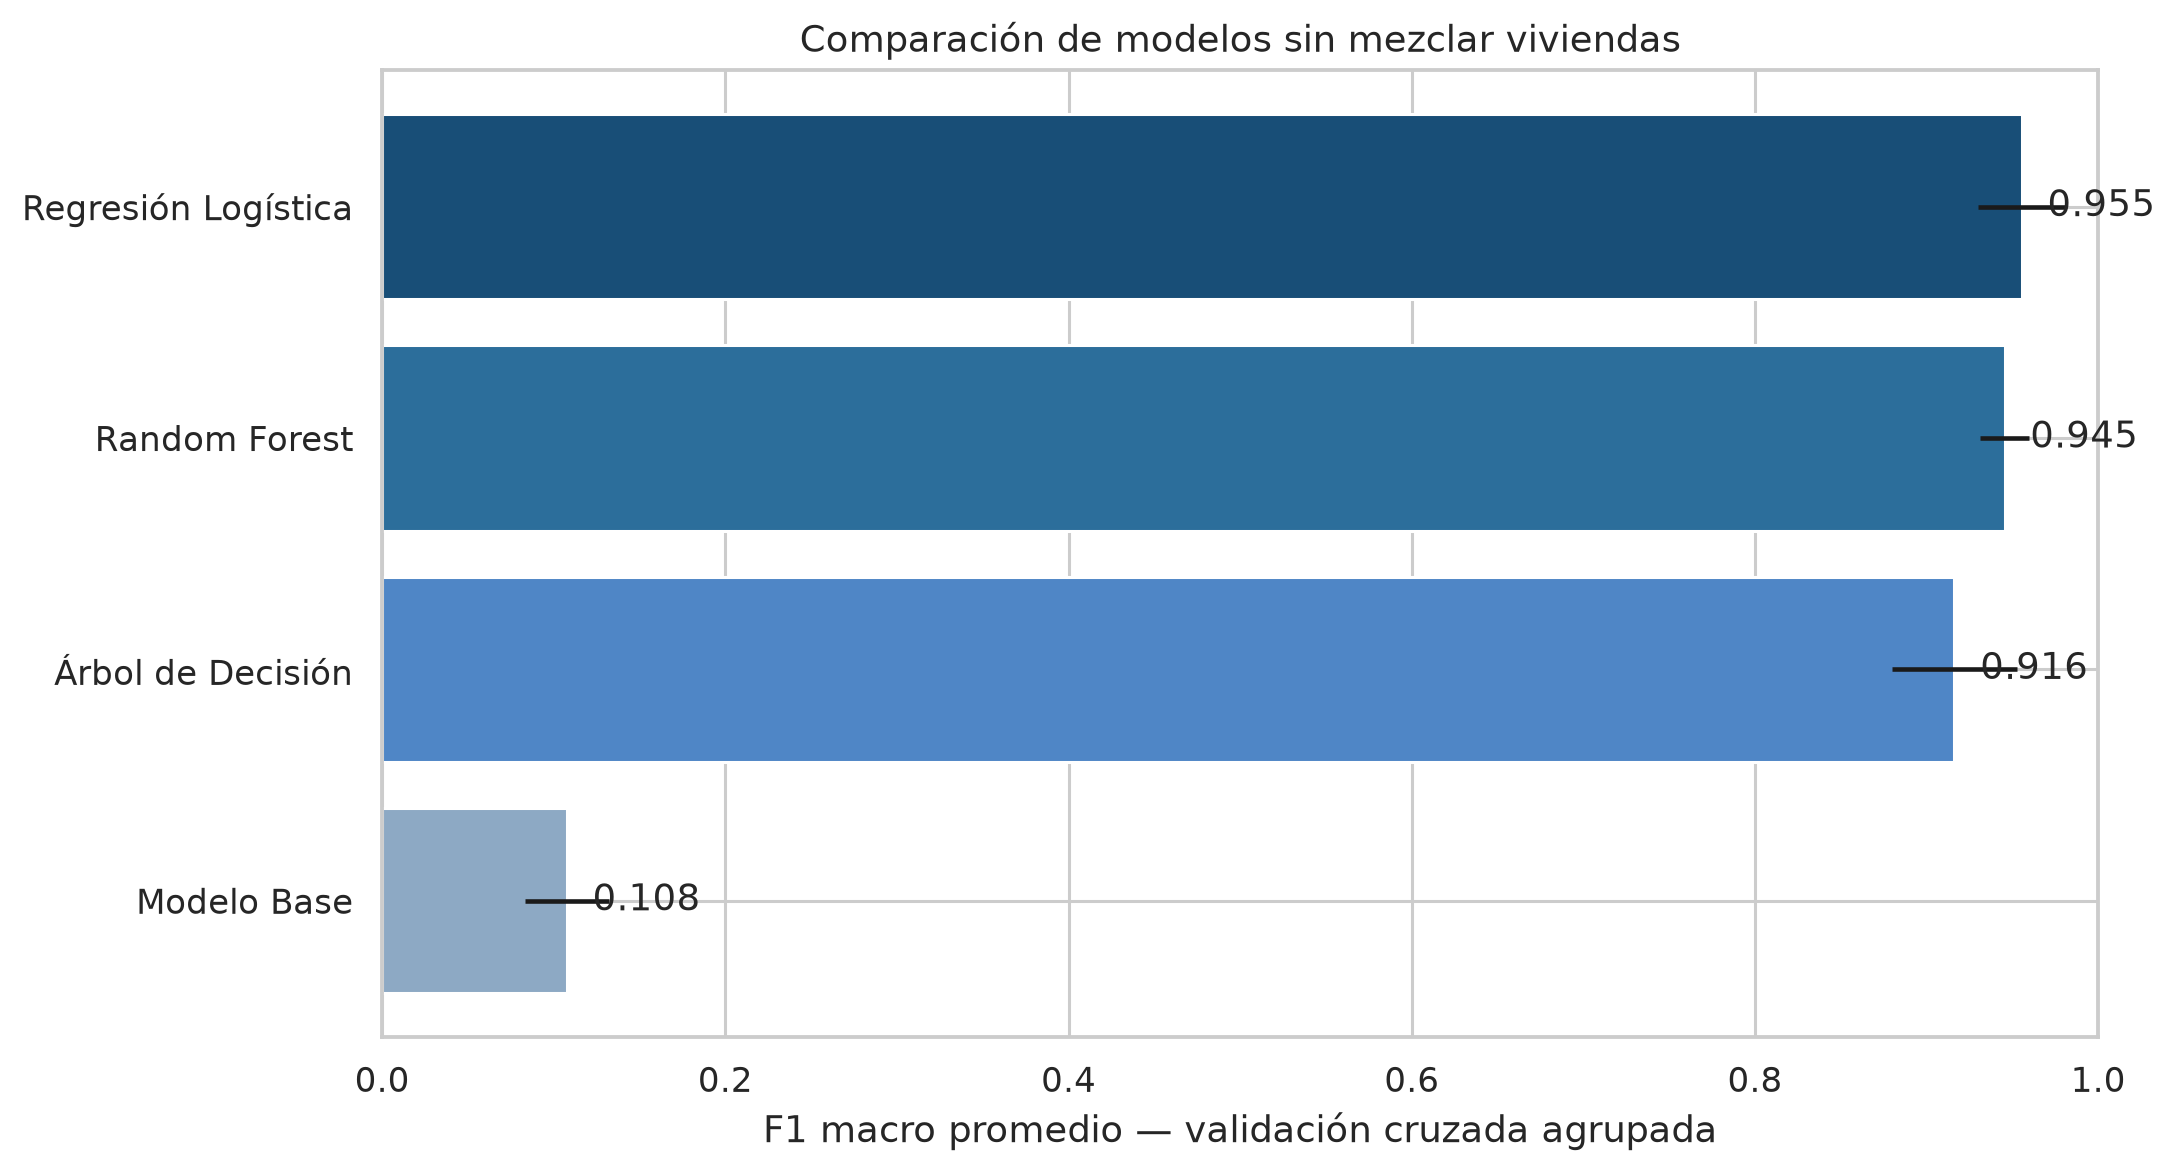

In [7]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 5.5))
plot_df = comparison_df.sort_values("cv_f1_macro_promedio")
ax.barh(
    plot_df["modelo"],
    plot_df["cv_f1_macro_promedio"],
    xerr=plot_df["cv_f1_macro_desv"],
    color=["#8DA9C4", "#4F86C6", "#2C6E9B", "#184E77"],
)
ax.set_xlim(0, 1)
ax.set_xlabel("F1 macro promedio — validación cruzada agrupada")
ax.set_ylabel("")
ax.set_title("Comparación de modelos sin mezclar viviendas")
for index, value in enumerate(plot_df["cv_f1_macro_promedio"]):
    ax.text(value + 0.015, index, f"{value:.3f}", va="center")
fig.tight_layout()
fig.savefig(REPORTS_DIR / "cv_model_comparison.png", dpi=220, bbox_inches="tight")
plt.show()

## 5. Selección y evaluación final

El modelo con mayor F1 macro de validación cruzada se evalúa una sola vez
sobre las 124 filas de test reservadas.

In [8]:
winner_name = comparison_df.iloc[0]["modelo"]
winner_search = searches[winner_name]
best_model = winner_search.best_estimator_

y_pred = best_model.predict(X_test)
y_probability = best_model.predict_proba(X_test)

test_metrics = {
    "modelo_seleccionado": winner_name,
    "criterio_seleccion": "Mayor F1 macro en StratifiedGroupKFold de 5 folds sobre train",
    "cv_f1_macro": float(winner_search.best_score_),
    "test_accuracy": float(accuracy_score(y_test, y_pred)),
    "test_balanced_accuracy": float(balanced_accuracy_score(y_test, y_pred)),
    "test_f1_macro": float(f1_score(y_test, y_pred, average="macro")),
    "test_f1_weighted": float(f1_score(y_test, y_pred, average="weighted")),
    "train_rows": int(len(train_df)),
    "test_rows": int(len(test_df)),
    "train_homes": int(train_df[GROUP_COLUMN].nunique()),
    "test_homes": int(test_df[GROUP_COLUMN].nunique()),
    "best_params": winner_search.best_params_,
    "feature_columns": FEATURE_COLUMNS,
    "target_column": TARGET_COLUMN,
    "class_order": CLASS_ORDER,
    "random_state": RANDOM_STATE,
    "sklearn_version": sklearn.__version__,
    "serialization_scope": "Delegado al equipo de Backend; no incluido en esta entrega.",
}

with (REPORTS_DIR / "final_test_metrics.json").open("w", encoding="utf-8") as file:
    json.dump(test_metrics, file, ensure_ascii=False, indent=2)

print(json.dumps(test_metrics, ensure_ascii=False, indent=2))

{
  "modelo_seleccionado": "Regresión Logística",
  "criterio_seleccion": "Mayor F1 macro en StratifiedGroupKFold de 5 folds sobre train",
  "cv_f1_macro": 0.9554069794381445,
  "test_accuracy": 0.9435483870967742,
  "test_balanced_accuracy": 0.9510095994703741,
  "test_f1_macro": 0.9441585632874531,
  "test_f1_weighted": 0.943859361136075,
  "train_rows": 431,
  "test_rows": 124,
  "train_homes": 113,
  "test_homes": 38,
  "best_params": {
    "model__C": 10.0,
    "model__class_weight": null
  },
  "feature_columns": [
    "consumo_kwh",
    "uso_horario_pico",
    "cantidad_equipos",
    "tipo_inmueble",
    "horas_alto_consumo"
  ],
  "target_column": "categoria",
  "class_order": [
    "Eficiente",
    "Moderado",
    "Ineficiente"
  ],
  "random_state": 42,
  "sklearn_version": "1.7.2",
  "serialization_scope": "Delegado al equipo de Backend; no incluido en esta entrega."
}


In [9]:
report_dict = classification_report(
    y_test,
    y_pred,
    labels=CLASS_ORDER,
    output_dict=True,
    zero_division=0,
)
classification_df = pd.DataFrame(report_dict).transpose()
classification_df.to_csv(REPORTS_DIR / "classification_report.csv")
display(classification_df)

              precision    recall  f1-score     support
Eficiente      1.000000  0.905660  0.950495   53.000000
Moderado       0.878049  0.947368  0.911392   38.000000
Ineficiente    0.942857  1.000000  0.970588   33.000000
accuracy       0.943548  0.943548  0.943548    0.943548
macro avg      0.940302  0.951010  0.944159  124.000000
weighted avg   0.947420  0.943548  0.943859  124.000000

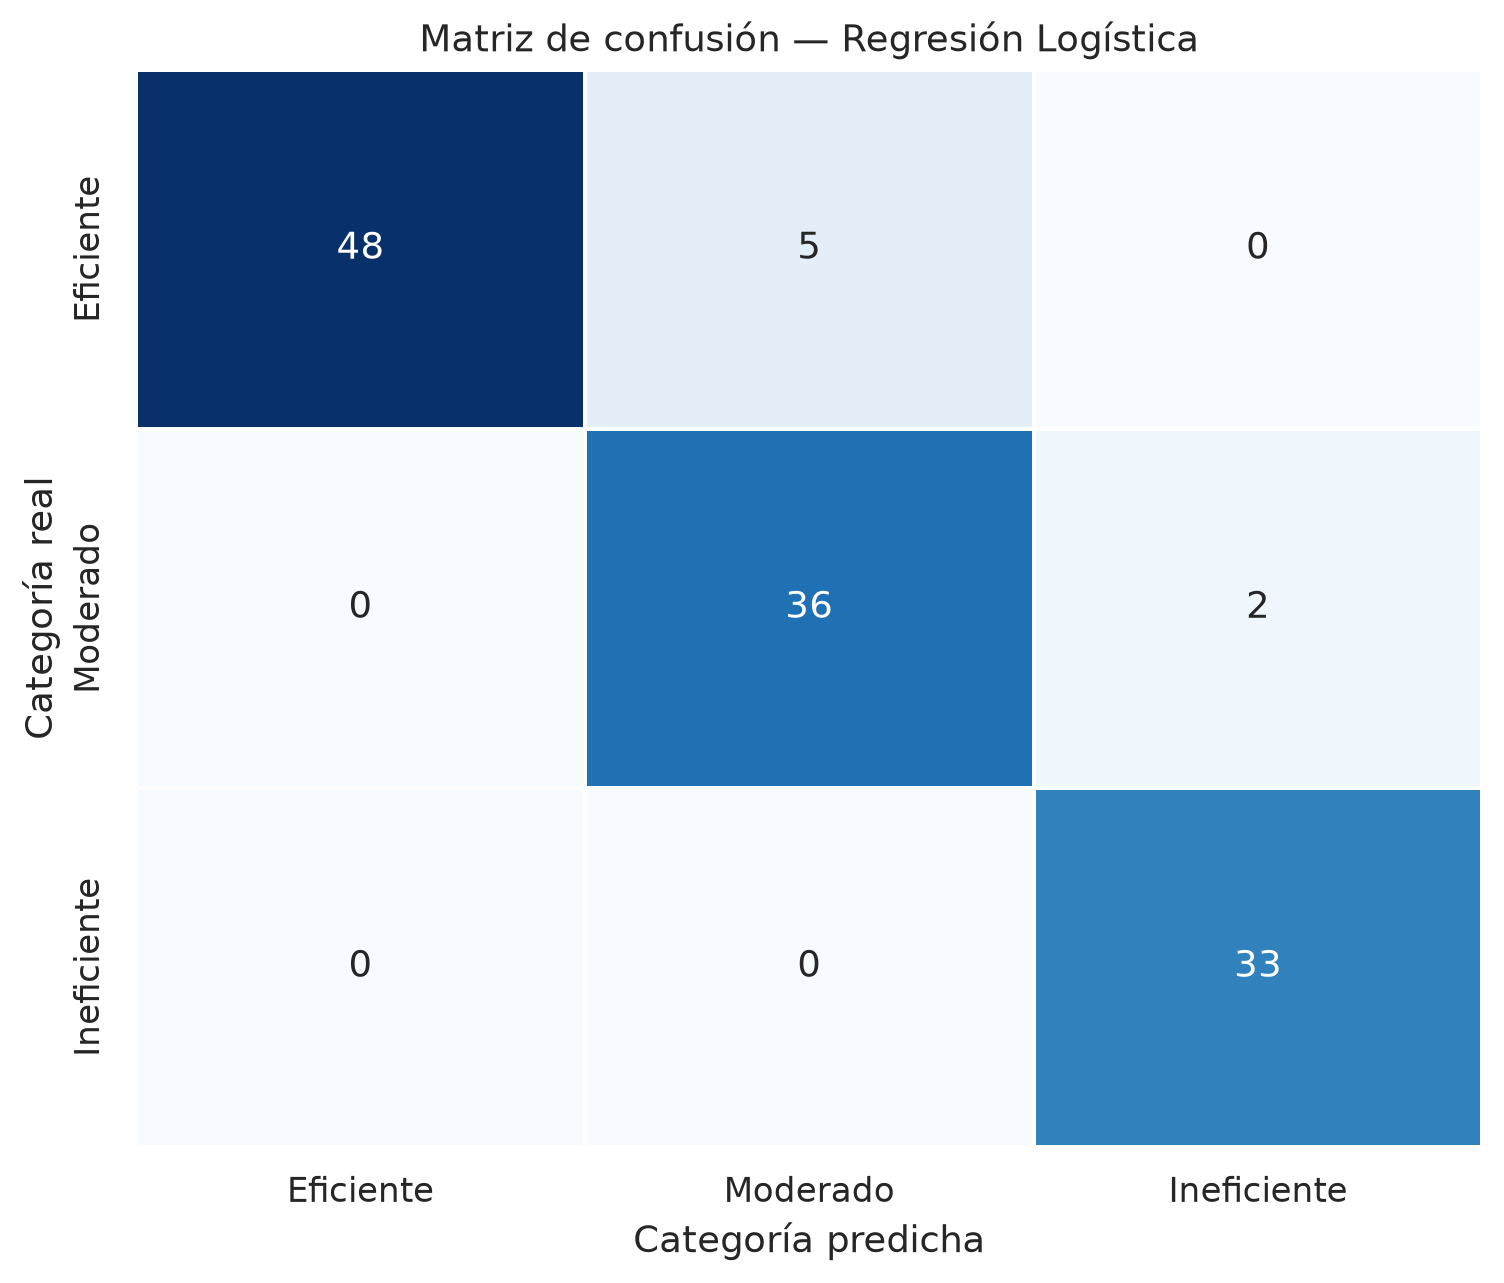

In [10]:
matrix = confusion_matrix(y_test, y_pred, labels=CLASS_ORDER)
matrix_df = pd.DataFrame(matrix, index=CLASS_ORDER, columns=CLASS_ORDER)
matrix_df.to_csv(REPORTS_DIR / "confusion_matrix.csv")

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    matrix_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    linewidths=0.8,
    ax=ax,
)
ax.set_xlabel("Categoría predicha")
ax.set_ylabel("Categoría real")
ax.set_title(f"Matriz de confusión — {winner_name}")
fig.tight_layout()
fig.savefig(REPORTS_DIR / "confusion_matrix.png", dpi=220, bbox_inches="tight")
plt.show()

## 6. Importancia por permutación

Se mide cuánto cae el F1 macro al desordenar cada variable del conjunto de
prueba. Es una explicación descriptiva del modelo, no una relación causal.

In [11]:
importance = permutation_importance(
    best_model,
    X_test,
    y_test,
    scoring="f1_macro",
    n_repeats=30,
    random_state=RANDOM_STATE,
    n_jobs=1,
)

importance_df = (
    pd.DataFrame(
        {
            "variable": FEATURE_COLUMNS,
            "importancia_promedio": importance.importances_mean,
            "importancia_desv": importance.importances_std,
        }
    )
    .sort_values("importancia_promedio", ascending=False)
    .reset_index(drop=True)
)
importance_df.to_csv(REPORTS_DIR / "feature_importance.csv", index=False)
display(importance_df)

          variable  importancia_promedio  importancia_desv
       consumo_kwh              0.496174          0.042521
  uso_horario_pico              0.244058          0.029150
horas_alto_consumo              0.161789          0.028919
     tipo_inmueble              0.123469          0.030896
  cantidad_equipos              0.030437          0.015537

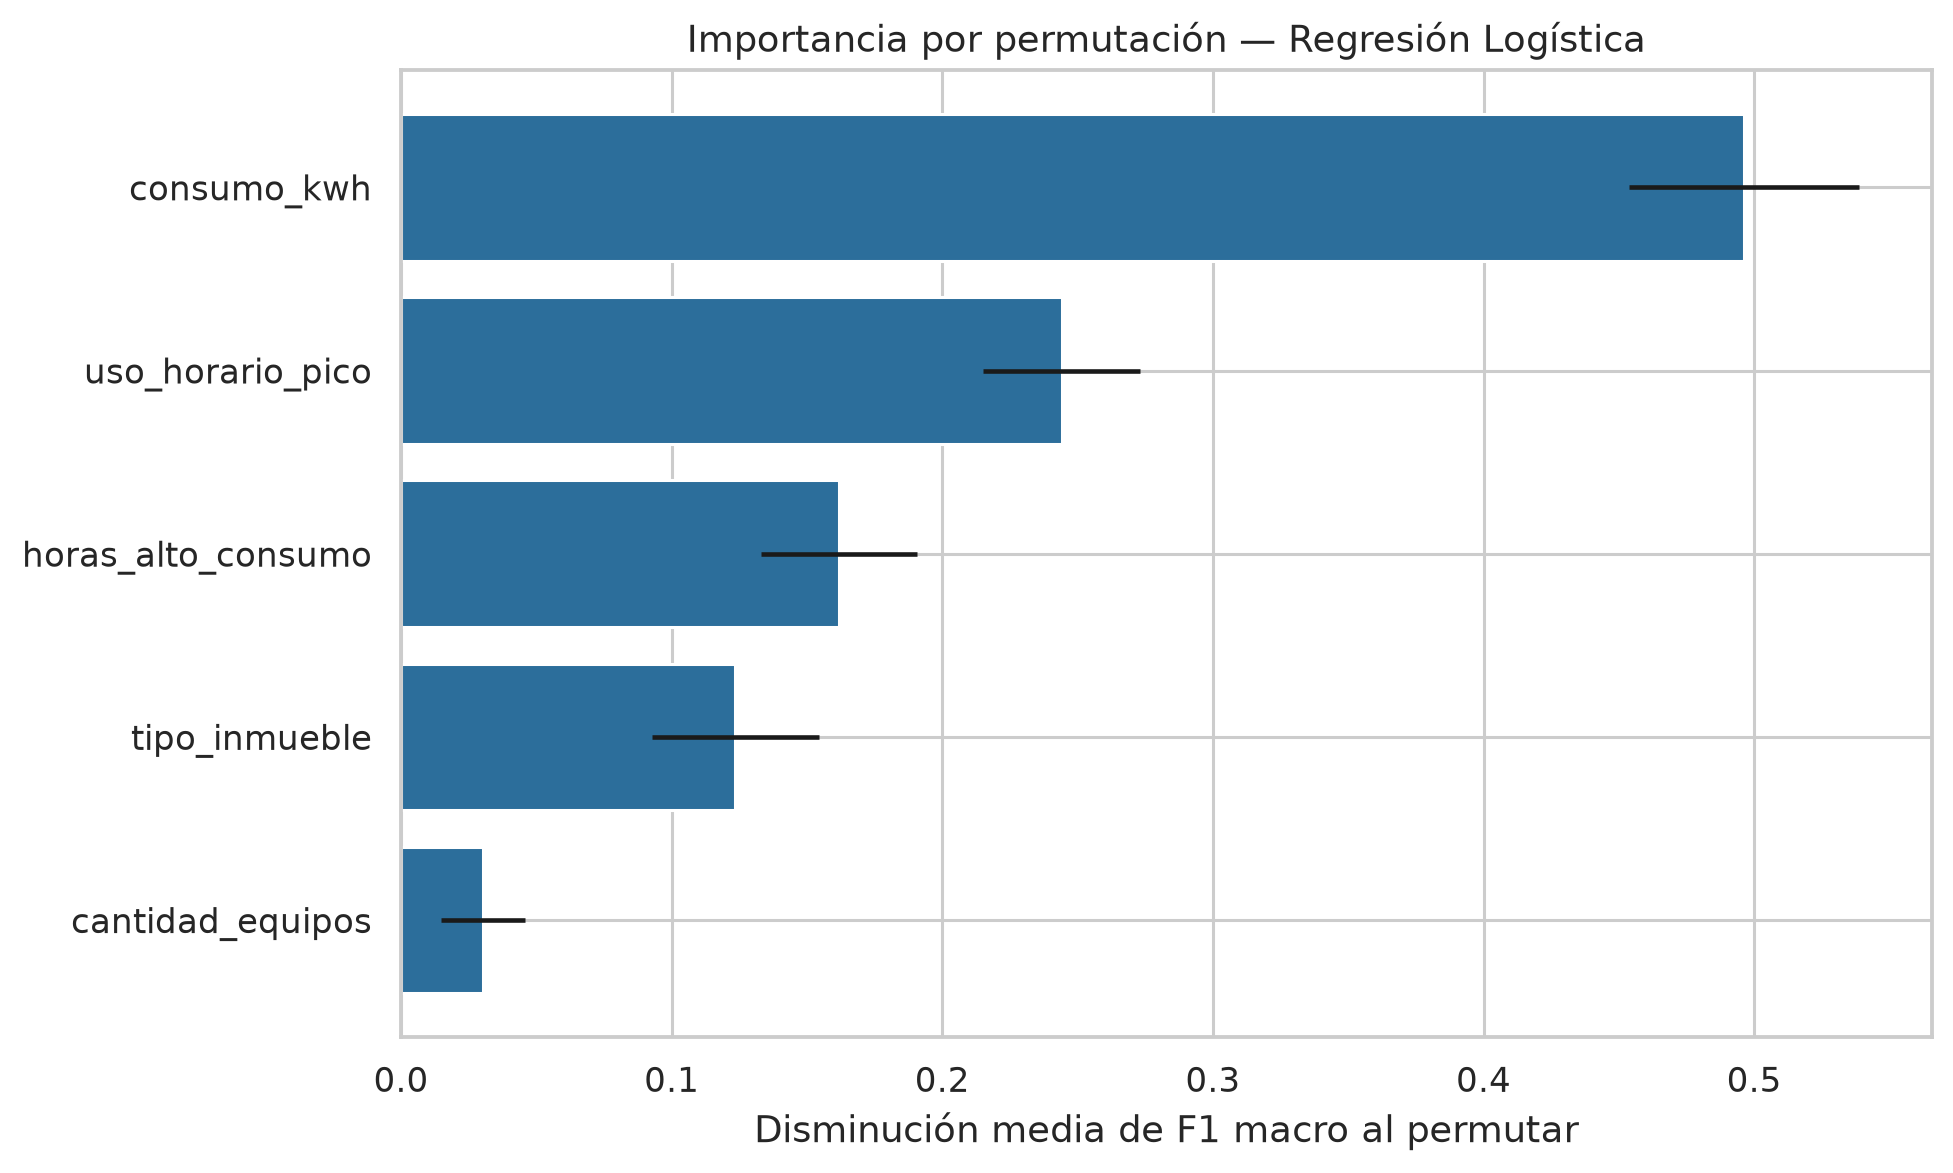

In [12]:
fig, ax = plt.subplots(figsize=(9, 5.5))
plot_importance = importance_df.sort_values("importancia_promedio")
ax.barh(
    plot_importance["variable"],
    plot_importance["importancia_promedio"],
    xerr=plot_importance["importancia_desv"],
    color="#2C6E9B",
)
ax.set_xlabel("Disminución media de F1 macro al permutar")
ax.set_ylabel("")
ax.set_title(f"Importancia por permutación — {winner_name}")
fig.tight_layout()
fig.savefig(REPORTS_DIR / "feature_importance.png", dpi=220, bbox_inches="tight")
plt.show()

## 7. Tres pruebas funcionales

Se muestran casos de las tres categorías reales. Estas pruebas comprueban que
el pipeline acepta exactamente las cinco variables del endpoint y devuelve
una categoría junto con su probabilidad máxima.

In [13]:
examples = (
    test_df.groupby(TARGET_COLUMN, observed=True, group_keys=False)
    .head(1)
    .copy()
)
example_predictions = best_model.predict(examples[FEATURE_COLUMNS])
example_probabilities = best_model.predict_proba(examples[FEATURE_COLUMNS])

examples_output = examples[FEATURE_COLUMNS + [TARGET_COLUMN]].copy()
examples_output["categoria_predicha"] = example_predictions
examples_output["probabilidad"] = example_probabilities.max(axis=1)
examples_output.to_csv(REPORTS_DIR / "prediction_examples.csv", index=False)
display(examples_output)

 consumo_kwh  uso_horario_pico  cantidad_equipos tipo_inmueble  horas_alto_consumo   categoria categoria_predicha  probabilidad
  115.546342              True                 6  Departamento                   1   Eficiente          Eficiente      0.969627
  346.912850              True                12          Casa                   7 Ineficiente        Ineficiente      0.999375
  291.777720             False                12          Casa                   5    Moderado           Moderado      0.948533

## 8. Conclusión

- La selección se hizo con validación cruzada agrupada por vivienda.
- El conjunto de prueba permaneció aislado hasta elegir el modelo ganador.
- Las cinco variables coinciden con el contrato del endpoint.
- Las categorías son pseudoetiquetas relativas, no certificaciones oficiales.
- Datos exporta y valida el modelo en joblib/ONNX mediante
  `scripts/export_model_artifacts.py`.
- Back-End carga el ONNX desde Java y DevOps gestiona su despliegue en OCI.